Saving sample_sales_1.csv to sample_sales_1 (1).csv
Rows and Columns: (8, 6)
Duplicate Rows Count: 0
Missing Values: order_id      0
order_date    0
region        0
product       0
quantity      0
unit_price    0
dtype: int64
Q1: 1337.5 Q3: 53500.0
New Average unit_price without outliers: 24456.25


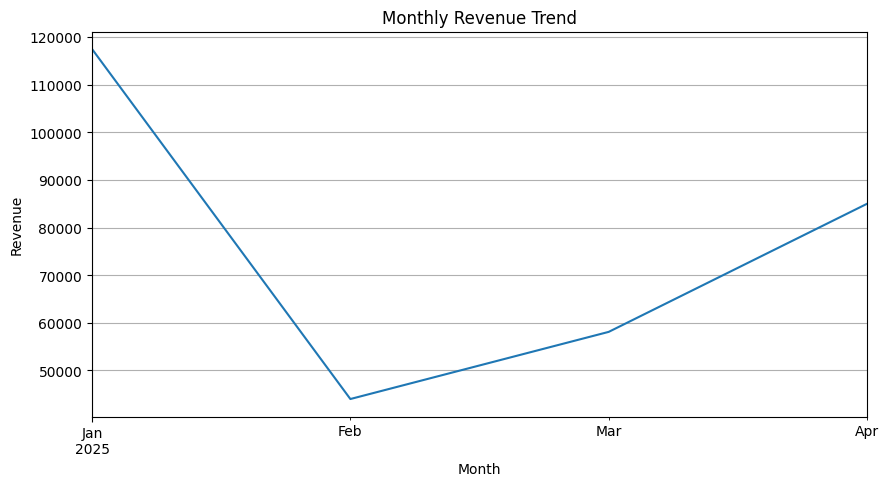

In [3]:
# 1) sample_sales.csv

# Columns: order_id, order_date, region, product, quantity, unit_price

# How many rows and columns are in the file?

# Are there any duplicate rows? If yes, how many and which order_ids repeat?

# How many missing values are there in each column?

# What is total revenue (quantity * unit_price) overall?

# What’s the average quantity and unit_price per product?

# Show monthly total revenue (group by month of order_date). Which month is highest?

# Create a Month × region pivot of revenue. Which region leads in the most months?

# Top 5 products by total revenue.

# For each region, what percent of total revenue does it contribute?

# Find orders where unit_price is an outlier (use 1.5×IQR). How many such rows?

# After removing outlier prices, what’s the new average unit_price?

# Plot monthly revenue and comment on any trend or seasonality you notice (even a simple up/down note).

from google.colab import files
uploaded=files.upload()
import pandas as pd
import matplotlib.pyplot as plt
df=pd.read_csv("sample_sales_1.csv",parse_dates=["order_date"])
print("Rows and Columns:",df.shape)
duplicates=df[df.duplicated()]
print("Duplicate Rows Count:",len(duplicates))
duplicate_ids=df[df.duplicated("order_id",keep=False)]["order_id"].value_counts()
print("Missing Values:",df.isnull().sum())
df["revenue"]=df["quantity"]*df["unit_price"]
Total_revenue=df["revenue"].sum()
avg_stats=df.groupby("product")[["quantity","unit_price"]].mean()
df["month"]=df["order_date"].dt.to_period("M")
monthly_revenue=df.groupby("month")["revenue"].sum()
highest_month=monthly_revenue.idxmax()
pivot=df.pivot_table(values="revenue",index="month",columns="region",aggfunc="sum",fill_value=0)
top_region_months=pivot.idxmax(axis=1).value_counts()
top_products=df.groupby("product")["revenue"].sum().sort_values(ascending=False).head(5)
region_contribution=df.groupby("region")["revenue"].sum()/Total_revenue*100
Q1=df["unit_price"].quantile(0.25)
Q3=df["unit_price"].quantile(0.75)
print("Q1:",Q1,"Q3:",Q3)
IQR=Q3-Q1
lower=Q1-1.5*IQR
upper=Q3+1.5*IQR
outlier=df[(df["unit_price"]<lower) | (df["unit_price"]>upper)]
df_clean=df[(df["unit_price"]>=lower) & (df["unit_price"]<=upper)]
print("New Average unit_price without outliers:",df_clean["unit_price"].mean())
monthly_revenue.plot(kind="line",title="Monthly Revenue Trend",figsize=(10,5))
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.grid(True)
plt.show()